# Password Security - Input live

Acest proiect verifică dacă o parolă este sigură și nu conține ID-ul utilizatorului.

**Funcții:**
- verificare lungime
- litere mari și mici
- cifre
- caractere speciale
- verificare dacă parola conține ID-ul
- scor și nivel de securitate
- verificare parole compromise
- salvare în baza de date a ID-ului, hash, scor, nivel și status compromisa
- grafice pentru distribuție nivel parole și parole compromise

In [1]:
# IMPORTURI BIBLIOTECI SI CONECTAREA LA DB

import re
import hashlib
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Conectare PostgreSQL
DB_PASSWORD = "postgres"  # parola ta reală

conn = psycopg2.connect(
    host="localhost",
    database="proiect_parola_db",
    user="postgres",
    password=DB_PASSWORD
)

cur = conn.cursor()
print("Conectare la baza de date reușită!")

Conectare la baza de date reușită!


In [2]:
# Functii pentru scor, nivel si verificare ID

def verificare_parola(parola, user_id=None):
    scor = 0
    if len(parola) >= 8: scor += 1
    if re.search("[A-Z]", parola): scor += 1
    if re.search("[a-z]", parola): scor += 1
    if re.search("[0-9]", parola): scor += 1
    if re.search(r"[!@#$%^&*()_+=\-{}[\]:;\"'<>,.?/]", parola): scor += 1
    
    # verificare daca parola contine ID-ul
    if user_id:
        if user_id.lower() in parola.lower():
            scor = min(scor, 1)  # scade scorul la 1
            print(" Parola conține ID-ul utilizatorului!")

    return scor

def clasificare_parola(scor):
    if scor <= 2:
        return "slaba"
    elif scor <= 4:
        return "medie"
    else:
        return "puternica"

def parola_compromisa(parola):
    try:
        with open("parole_compromise.txt","r") as f:
            lista = f.read().splitlines()
        return parola in lista
    except FileNotFoundError:
        print(" Fisierul parole_compromise.txt nu a fost gasit.")
        return False

def salveaza_parola(user_id, hash_parola, scor, nivel, compromisa):
    try:
        cur.execute(
            "INSERT INTO verificare_parola (user_id, parola, scor, nivel, compromisa) VALUES (%s,%s,%s,%s,%s)",
            (user_id, hash_parola, scor, nivel, compromisa)
        )
        conn.commit()
    except Exception as e:
        print("Eroare la inserare:", e)

In [3]:
# Input live pentru ID si parola

# Input live
user_id = input("Introduceți ID-ul utilizatorului (ex: nume.prenume): ").strip()
parola = input("Introduceți parola: ").strip()

scor = verificare_parola(parola, user_id)
nivel = clasificare_parola(scor)
hash_parola = hashlib.sha256(parola.encode()).hexdigest()
compromisa = parola_compromisa(parola)

# Salvare in DB
salveaza_parola(user_id, hash_parola, scor, nivel, compromisa)

# Afisare rezultate
print("----------------------------")
print(f"ID Utilizator: {user_id}")
print(f"Parola: {'*'*len(parola)}")  # nu afișăm parola reală
print(f"Scor: {scor}, Nivel: {nivel}")
print(f"Hash: {hash_parola}")
print(f"Compromisa: {compromisa}")



Introduceți ID-ul utilizatorului (ex: nume.prenume):  cristian.stefan
Introduceți parola:  stef12!


----------------------------
ID Utilizator: cristian.stefan
Parola: *******
Scor: 3, Nivel: medie
Hash: 32fe67fec13f5c170977128752d82a70ee69515bd9fbb9685230b856aca9d0f3
Compromisa: False


In [4]:
cur.execute("SELECT * FROM verificare_parola")
rezultat = cur.fetchall()

# Adaugăm toate cele 6 coloane
df = pd.DataFrame(rezultat, columns=["id", "user_id", "parola", "scor", "nivel", "compromisa"])
df

,id,user_id,parola,scor,nivel,compromisa
0,1,aron.alexandra,2612353cfaaf8eecc32e56c22b80d673714a6d12d9e56c...,3,medie,False
1,2,alexandra.aron,2612353cfaaf8eecc32e56c22b80d673714a6d12d9e56c...,3,medie,False
2,3,cristian.stefan,008f448ce68d63cebb9941f0c7be6e382f2a3a15b197ce...,3,medie,False
3,4,cristian.stefan,32fe67fec13f5c170977128752d82a70ee69515bd9fbb9...,3,medie,False


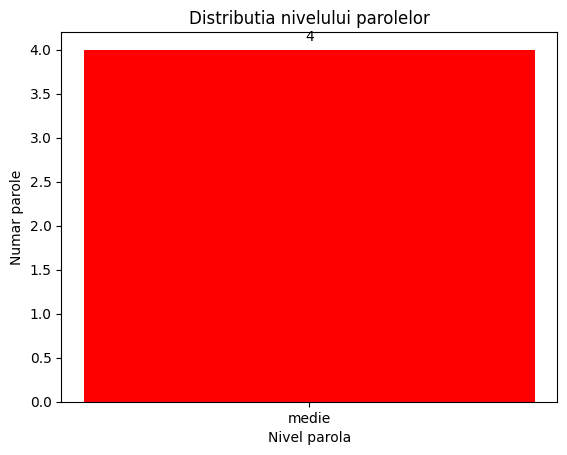

In [5]:
# Bar chart - distributie niveluri parole

cur.execute("SELECT nivel FROM verificare_parola")
niveluri = [row[0] for row in cur.fetchall()]
count = Counter(niveluri)

plt.bar(count.keys(), count.values(), color=['red', 'orange', 'green'])
plt.title("Distributia nivelului parolelor")
plt.xlabel("Nivel parola")
plt.ylabel("Numar parole")

for i, val in enumerate(count.values()):
    plt.text(i, val + 0.1, str(val), ha='center')
plt.show()

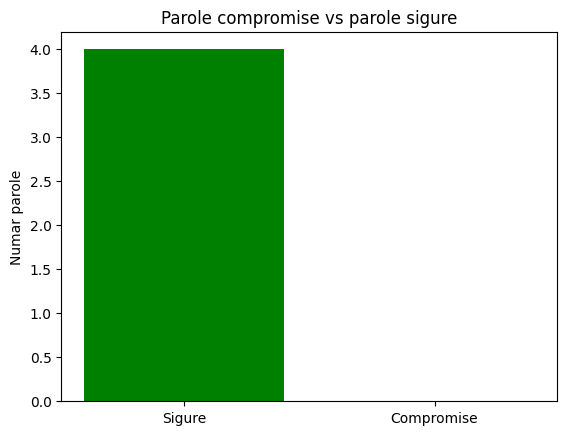

In [6]:
# Bar chart - parole compromise 

cur.execute("SELECT compromisa FROM verificare_parola")
compromise = [row[0] for row in cur.fetchall()]
count_comp = Counter(compromise)

plt.bar(["Sigure", "Compromise"], [count_comp.get(False,0), count_comp.get(True,0)],
        color=['green','red'])
plt.title("Parole compromise vs parole sigure")
plt.ylabel("Numar parole")
plt.show()

In [7]:
# Inchide conexiunea DB
cur.close()
conn.close()
print("Conexiunea la baza de date a fost inchisa.")

Conexiunea la baza de date a fost inchisa.
